In [28]:
import pandas as pd 

Charger le fichier CSV

In [29]:
df = pd.read_csv('typhoide_health_data.csv')

# EXERCICE 1 : Exploration initiale et porfilage des donnees

Le Nombre de ligne uniquement

In [30]:
df.shape[0]

300

Le Nombre de colonnes 

In [31]:
df.shape[1]

9

TYPES DE DONNEES DE CHAQUES VARIABLE

# C’est quoi int64 ?

int64 signifie :

Nombre entier stocké sur 64 bits

 C’est un type de données numérique utilisé pour des valeurs sans virgule.

 # C’est quoi float64 ?

float64 signifie :

Nombre décimal stocké sur 64 bits (en mémoire)

C’est un type de données numérique utilisé par Python (via NumPy / pandas).

In [32]:
df.dtypes

Age                       int64
Sexe                     object
Region                   object
Temperature             float64
Duree_fievre              int64
Test_typhoide            object
Source_eau               object
Acces_assainissement     object
Antibiotherapie          object
dtype: object

# 2.Identifier les valeurs manquantes : 
# isnull() → détecte les valeurs manquantes (NaN)
# sum() → les compte colonne par colonne
il affiche 0 il ya pas de valeur manquantes
Phrase pour le rapport

L’identification des valeurs manquantes a été réalisée à l’aide de la fonction isnull() de pandas. Le nombre de valeurs manquantes a été calculé pour chaque variable du jeu de données.

In [33]:
df.isnull().sum()


Age                     0
Sexe                    0
Region                  0
Temperature             0
Duree_fievre            0
Test_typhoide           0
Source_eau              0
Acces_assainissement    0
Antibiotherapie         0
dtype: int64

# Identifier les doublons
# Nombre total de lignes dupliquées
Phrase pour le rapport
La recherche de doublons a été effectuée à l’aide de la fonction duplicated(). Le nombre total de lignes dupliquées a été calculé automatiquement.

In [34]:
df.duplicated().sum()

0

# 3.Statistiques descriptives de l’âge
# count : 300
 300 patients ont un âge renseigné.
L’analyse porte sur 300 patients pour lesquels l’âge est renseigné.
# mean : 39.99
Âge moyen ≈ 40 ans
L’âge moyen des patients est d’environ 40 ans.
# std : 22.28
 Écart-type ≈ 22 ans
 L’écart-type élevé indique une forte variabilité des âges au sein de la population étudiée.
 # min : 1
Patient le plus jeune : 1 an
L’âge minimum observé est de 1 an.
# 25% : 20
25 % des patients ont 20 ans ou moins
Un quart des patients a un âge inférieur ou égal à 20 ans.
# 50% : 39.5
Âge médian = 39,5 ans
50 % des patients ont moins de 39,5 ans
50 % ont plus de 39,5 ans
# 75% : 58.25
75 % des patients ont 58,25 ans ou moins
Les trois quarts des patients ont un âge inférieur ou égal à 58,25 ans.
# max : 80
 Patient le plus âgé : 80 ans
L’âge maximum observé dans l’échantillon est de 80 ans.

In [35]:
df["Age"].describe()

count    300.000000
mean      39.993333
std       22.276462
min        1.000000
25%       20.000000
50%       39.500000
75%       58.250000
max       80.000000
Name: Age, dtype: float64

Statistiques descriptives de la durée de la fièvre

## Statistiques descriptives de la durée de la fièvre

L’analyse descriptive de la durée de la fièvre porte sur **300 patients**, ce qui indique que cette variable est entièrement renseignée dans le jeu de données.

La durée moyenne de la fièvre avant consultation est de **6,21 jours**, avec un écart-type de **3,10 jours**, traduisant une variabilité modérée entre les patients.

La durée minimale observée est de **1 jour**, tandis que la durée maximale atteint **14 jours**, ce qui suggère que certains patients consultent tardivement.

Le premier quartile indique que **25 % des patients présentent une durée de fièvre inférieure ou égale à 4 jours**.  
La médiane est de **6 jours**, ce qui signifie que la moitié des patients consultent après six jours ou moins de fièvre.  
Enfin, **75 % des patients ont une durée de fièvre inférieure ou égale à 8 jours**.

Dans l’ensemble, ces résultats montrent que la majorité des patients consultent après plusieurs jours de fièvre, ce qui peut avoir des implications importantes pour la prise en charge précoce de la fièvre typhoïde.

# Durée de la fièvre : de 1 à 14 jours, moyenne ≈ 6,2 jours, médiane 6 jours, dispersion modérée (écart-type 3,1 jours).
Ces statistiques montrent que le dataset est complet et fiable


In [36]:
df["Duree_fievre"].describe()

count    300.000000
mean       7.360000
std        3.994612
min        1.000000
25%        4.000000
50%        7.000000
75%       11.000000
max       14.000000
Name: Duree_fievre, dtype: float64

# 4.Explorer la distribution de la température corporelle et identifier les valeurs aberrantes
# Objectif
Analyser comment se répartit la température corporelle des individus et repérer les valeurs anormales (aberrantes).
# Méthodes utilisées
Statistiques descriptives (min, max, moyenne, quartiles)
Histogramme → forme de la distribution
Boxplot → détection des valeurs aberrantes

# À quoi sert Matplotlib ?

Matplotlib est une bibliothèque Python qui sert à créer des graphiques pour visualiser les données.

 Elle permet de voir les données au lieu de seulement lire des chiffres.

In [37]:
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

# Statistiques descriptives

In [38]:
df['Temperature'].describe()

count    300.000000
mean      38.543667
std        1.707311
min       35.500000
25%       37.100000
50%       38.600000
75%       40.000000
max       41.500000
Name: Temperature, dtype: float64

# Histogramme

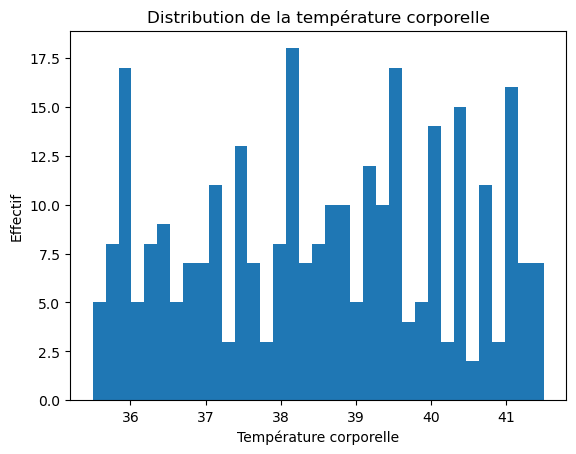

In [51]:
plt.hist(df['Temperature'], bins=35)
plt.xlabel("Température corporelle")
plt.ylabel("Effectif")
plt.title("Distribution de la température corporelle")
plt.show()

# interpretation 
La majorité des températures se situe entre 37 et 40 degrés. On observe quelques valeurs très basses ou très élevées qui peuvent être considérées comme des valeurs aberrantes

# Boxplot pour détecter les valeurs aberrantes(repérer les valeurs anormales)

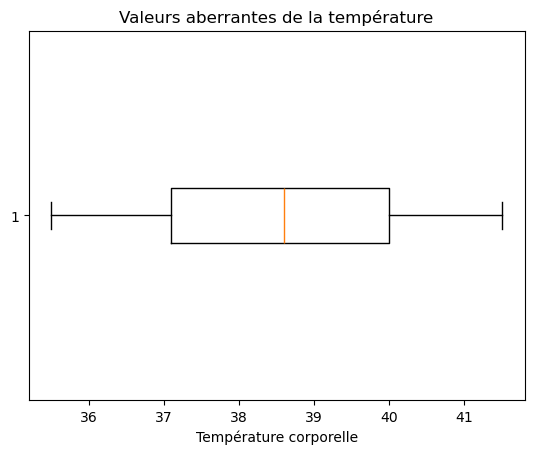

In [40]:
plt.boxplot(df['Temperature'], vert=False)
plt.xlabel("Température corporelle")
plt.title("Valeurs aberrantes de la température")
plt.show()

# observation 
Le boxplot montre que la majorité des températures se situe entre 37 et 40 degrés, avec une médiane autour de 38,5. Aucune valeur aberrante n’a été détectée.

# 5.Compter les valeurs uniques

Identifier la répartition des catégories pour certaines variables qualitatives.
# Comptage par sexe
Interprétation :
Cette analyse montre la répartition des individus selon le sexe dans l’échantillon.

In [41]:
df['Sexe'].value_counts()

Sexe
F    156
M    144
Name: count, dtype: int64

# Résultat du test typhoïde
Interprétation :
On observe le nombre de résultats positifs et négatifs au test de la typhoïde.

In [42]:
df['Test_typhoide'].value_counts()


Test_typhoide
Positif    185
Negatif    115
Name: count, dtype: int64

Interprétation simple

185 personnes ont un test positif à la typhoïde
 Elles sont considérées comme malades ou porteuses de la maladie.

115 personnes ont un test négatif
 Elles sont considérées comme non malades.

# Source d’eau
Interprétation :
Cette variable permet d’identifier les différentes sources d’eau utilisées par les individus et leur fréquence.


J’ai utilisé value_counts() pour compter les valeurs uniques du sexe, du test de la typhoïde et de la source d’eau afin d’analyser la structure de la population étudiée.

In [43]:
df['Source_eau'].value_counts()


Source_eau
Riviere    104
Puits       99
Potable     97
Name: count, dtype: int64

# Exercice 2 : Analyse descriptive et épidémiologique
Objectif : Identifier les tendances associées à la fièvre typhoïde.


# 1.	Comparer la température moyenne entre les patients :

o	testés positifs

o	testés négatifs
# Moyenne de la température selon le test typhoïde


In [44]:
df.groupby('Test_typhoide')['Temperature'].mean()

Test_typhoide
Negatif    37.936522
Positif    38.921081
Name: Temperature, dtype: float64

# Les patients positifs à la typhoïde ont en moyenne une température plus élevée que les patients négatifs, ce qui confirme que la fièvre est un signe important de la maladie.
a quoi sert groupby ,mean ?

# 1. groupby
Sert à regrouper les données par une ou plusieurs colonnes afin de faire des calculs sur chaque groupe.
# 2. mean()
Sert à calculer la moyenne des valeurs d’une série ou d’un groupe.
# lambda
C’est une fonction anonyme (une petite fonction définie à la volée) qu’on utilise souvent avec apply.
lambda x: (x=='Positif').sum() / len(x) * 100
Ici, x est un groupe de résultats (Positif ou Negatif).
(x=='Positif') crée une série de True/False

.sum() compte combien de True (donc combien de positifs)

/ len(x) * 100 calcule le pourcentage de positifs

# 2. Calculer le taux de positivité à la typhoïde par région

In [45]:
taux_positivite_region = df.groupby('Region')['Test_typhoide'].apply(
    lambda x: (x == 'Positif').sum() / len(x) * 100
)
print("\nTaux de positivité par région (%) :")
print(taux_positivite_region)


Taux de positivité par région (%) :
Region
Est      66.197183
Nord     56.944444
Ouest    65.263158
Sud      56.451613
Name: Test_typhoide, dtype: float64


<Axes: xlabel='Temperature', ylabel='Density'>

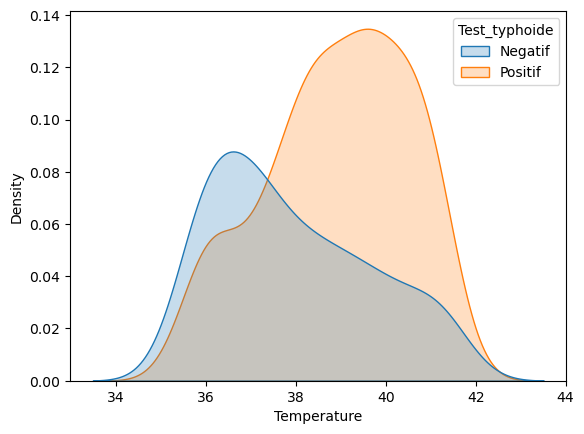

In [49]:
sns.kdeplot(data= df,x='Temperature',hue='Test_typhoide',fill=True)

# TAUX DE NEGAIVITE (AJOUTER MOI MEME IL YA PAS DANS LE DEVOIR)

In [ ]:
taux_negativite_region = df.groupby('Region')['Test_typhoide'].apply(
    lambda x: (x == 'Negatif').sum() / len(x) * 100
)
print("\nTaux de negativité par région (%) :")
print(taux_negativite_region)


Taux de negativité par région (%) :
Region
Est      33.802817
Nord     43.055556
Ouest    34.736842
Sud      43.548387
Name: Test_typhoide, dtype: float64


# 3. Évaluer si les personnes sans accès à l’assainissement sont plus souvent testées positives 
# Objectif
On veut savoir si le manque d’assainissement (toilettes, évacuation des eaux usées, etc.) est lié à un risque plus élevé de fièvre typhoïde.
Colonne utilisée : assainissement → Oui / Non
Colonne résultat : resultat_test → Positif / Negatif

# L’assainissement
 désigne l’ensemble des moyens et infrastructures qui permettent d’éliminer ou de traiter les déchets et les eaux usées pour protéger la santé des populations et l’environnement.

In [56]:
Taux_assainissement = df.groupby('Acces_assainissement')['Test_typhoide'].apply(
    lambda x: (x == 'Positif').sum() / len(x) * 100
)
print("\nTaux de positivité selon l'assainissement (%) :")
print(Taux_assainissement)


Taux de positivité selon l'assainissement (%) :
Acces_assainissement
Non    64.383562
Oui    59.090909
Name: Test_typhoide, dtype: float64


# 4. Comparer la durée moyenne de la fièvre entre patients positifs et négatifs

In [ ]:
duree_pos = df[df['Test_typhoide'] == 'Positif']['Duree_fievre'].mean()
duree_neg = df[df['Test_typhoide'] == 'Negatif']['Duree_fievre'].mean()

print(f"\nDurée moyenne de la fièvre (positifs) : {duree_pos:.2f} jours")
print(f"Durée moyenne de la fièvre (négatifs) : {duree_neg:.2f} jours")


Durée moyenne de la fièvre (positifs) : 8.16 jours
Durée moyenne de la fièvre (négatifs) : 6.08 jours


# 5.	Analyser l’association entre la source d’eau et le résultat du test

Taux de positivité selon la source d'eau

In [57]:
Taux_source_eau = df.groupby('Source_eau')['Test_typhoide'].apply(
    lambda x: (x == 'Positif').sum() / len(x) * 100
)
print("\nTaux de positivité selon la source d'eau (%) :")
print(Taux_source_eau)


Taux de positivité selon la source d'eau (%) :
Source_eau
Potable    64.948454
Puits      59.595960
Riviere    60.576923
Name: Test_typhoide, dtype: float64


# Exercice 3 : Analyse de la qualité des données
Objectif : Identifier et proposer des solutions aux problèmes de données.


# 1. Identifier les valeurs de température physiologiquement impossibles
But : repérer les valeurs de température qui ne peuvent pas exister chez un humain vivant.

Exemples : 30°C (hypothermie extrême), 45°C (hyperthermie extrême), 100°C (impossible !).

Problème : Ces valeurs peuvent fausser les calculs de moyenne, d’écart-type et induire des conclusions erronées.

# Identifier les températures impossibles (<35 ou >42)

In [ ]:
temp_impossibles = df[(df['Temperature'] < 35) | (df['Temperature'] > 42)]
print("Valeurs de température physiologiquement impossibles :")
print(temp_impossibles)

Valeurs de température physiologiquement impossibles :
Empty DataFrame
Columns: [Age, Sexe, Region, Temperature, Duree_fievre, Test_typhoide, Source_eau, Acces_assainissement, Antibiotherapie]
Index: []


# Interprétation
Empty DataFrame = le DataFrame est vide, il n’y a aucune ligne qui correspond à la condition que tu as mise 

Conclusion simple
Tes données sont cohérentes pour la température : toutes les valeurs sont dans la plage physiologique normale (35°C à 42°C).
Il n’y a donc pas de problème à corriger pour la température. 
En résumé pour ton rapport :

Après vérification, aucune température physiologiquement impossible n’a été détectée dans le dataset. Toutes les valeurs sont comprises entre 35°C et 42°C, ce qui est cohérent pour des patients humains.

# 2. Compter les valeurs manquantes dans la variable Durée_fièvre

But : savoir combien de patients n’ont pas de donnée pour la durée de fièvre.

Discussion :

Suppression → retirer les lignes avec des valeurs manquantes. Simple mais perte d’informations.

Imputation → remplacer les valeurs manquantes par une moyenne, médiane ou valeur prédite.

Conservation → garder les valeurs manquantes et gérer lors de l’analyse (ex : Pandas ignore NaN).

# Compter les valeurs manquantes

In [ ]:
nb_manquantes = df['Duree_fievre'].isna().sum()
print(f"Nombre de valeurs manquantes dans Durée_fièvre : {nb_manquantes}")

# Exemple d'imputation avec la moyenne
df['Duree_fievre'].fillna(df['Duree_fievre'].mean(), inplace=True)

Nombre de valeurs manquantes dans Durée_fièvre : 0


C:\Users\EL GENIE\AppData\Local\Temp\ipykernel_17084\3048303832.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Duree_fievre'].fillna(df['Duree_fievre'].mean(), inplace=True)


# Question 2  voir dimitri

# 3. Vérifier les incohérences dans certaines colonnes
# M -> M, F -> F, masculin -> M, féminin -> F
a.Sexe

Problème : certaines entrées peuvent être incohérentes ou mal formatées (M, m, Masculin, F, f, Féminin…).

Solution : uniformiser les valeurs.

# Standardiser: rendre les données uniformes et cohérentes, en transformant les valeurs pour qu’elles suivent un même format ou une même convention.

Standardiser le sexe

In [ ]:
df['Sexe'] = df['Sexe'].str.upper()  # M -> M, F -> F, masculin -> M, féminin -> F
df['Sexe'] = df['Sexe'].replace({'MASCULIN':'M','FEMININ':'F'})

# b Test_typhoide

Problème : différentes façons d’écrire positif/négatif (positif, Positif, POSITIF…).

Solution : uniformiser les valeurs.

# Standardiser Test_typhoide
POSITIF/NÉGATIF

In [ ]:
df['Test_typhoide'] = df['Test_typhoide'].str.upper()

 # 4. Proposer des règles de validation pour garantir la qualité future des données

Température : 35 <= temperature <= 42

Sexe : uniquement M ou F

Test_typhoide : uniquement POSITIF ou NEGATIF

Durée de fièvre : valeurs ≥ 0 et non manquantes si possible

Source d’eau / Assainissement : valeurs prédéfinies (ex : eau_puits, eau_robinet, Oui/Non)


# Résumé pour le rapport :

Identifier les valeurs aberrantes et manquantes permet de prévenir les erreurs d’analyse.

Standardiser les colonnes comme Sexe et Test_typhoide permet d’avoir un jeu de données propre et uniforme.

Proposer des règles de validation assure que les futurs enregistrements soient corrects.

In [ ]:
# Exemple de validation
invalid_temp = df[(df['Temperature'] < 35) | (df['Temperature'] > 42)]
invalid_sexe = df[~df['Sexe'].isin(['M','F'])]
invalid_test = df[~df['Test_typhoide'].isin(['POSITIF','NEGATIF'])]

print("Températures invalides :", len(invalid_temp))
print("Sexe invalide :", len(invalid_sexe))
print("Test_typhoide invalide :", len(invalid_test))


Températures invalides : 0
Sexe invalide : 0
Test_typhoide invalide : 0


Exercice 4 : Réflexion et rapport (Analyse critique)
Exercice 4:
Résumons les principaux problèmes de qualité des données observés Au cour de notre travail, nous avons exploré plusieurs problèmes de qualité que l'on retrouve généralement dans des jeux de données tels que: les valeurs manquantes, les températures physiologiquement impossibles, les incohérences dans les variables catégorielles, les formats non standard et les incohérences entre certaines variables. après toute cette exploration, nous n'avons trouvé aucun de ces problèmes dans notre jeu de données

Proposer des stratégies de nettoyage adaptées à chaque problème identifié Puisque nous n'avons pas trouvé de problèmes, nous n'avons pas se solutions

Mettons en évidence au moins trois facteurs de risque associés à la fièvre typhoïde à partir des données Nous avons: - La région: l'Est et l'Ouest sont les région les plus risquées - L'accès à l'assainissement: les personnes sans accès à l’assainissement sont plus souvent testées positives - La source d'eau: Les personnes utilisant des sources d’eau non traitées (puits, rivière) présentent des taux de positivité plus élevés

Listons de façon ordonnée les étapes de nettoyage et de transformation nécessaires avant une analyse avancée A- Valeurs manquantes
Certaines variables peuvent contenir des données manquantes 
Problème : perte d’information et biais possible si suppression ou mauvaise imputation.

       B- Valeurs aberrantes / physiologiquement impossibles

               Exemple: Températures hors plage réaliste : 30°C, 45°C, 100°C

       C- Incohérences dans les variables catégorielles

               Variations dans la saisie :
               Sexe : M, m, Masculin, F, féminin

       D- Problèmes de format

               Casse inconsistante (majuscules / minuscules)
               Caractères spéciaux ou espaces superflus

       E- Problèmes de cohérence entre variables

               Parfois les valeurs de certaines variables sont incompatibles :
               Exemple: Acces_assainissement = Non mais Source_eau = Robinet